# US Geographies and Silicon Valley Classification

This notebook visualizes the geographic distribution of ventures across all Metropolitan Statistical Areas (MSAs) in the United States and identifies Silicon Valley / Bay Area ventures. It constructs two versions of geographic figures:
1. **Bubble Map on US Outline**: A scatter plot of all MSAs overlaid on a continental United States outline, where bubble size represents venture count.
2. **MSA Shape Choropleth Map**: A map with shape objects (polygons) for all Census CBSAs/MSAs, color-coded by the quantity of entrepreneurial activity.

## 1. Variable Construction and Geography Definition

Geographic variables in the dataset are captured at both the pre-founding (prior position) and venture (post-founding) levels:
- **Prior Position Location (`prior_metro_area`, `prior_msa`, `prior_country`)**: Represents the location of the previous employer where the founder worked immediately prior to founding the startup.
- **Venture Location (`venture_metro_area`, `venture_msa`, `venture_country`)**: Represents the location where the founded venture is based.

### Silicon Valley (Bay Area) Identification
The Silicon Valley / Bay Area is defined as ventures located in the San Francisco or San Jose metropolitan areas. In terms of data variables:
- `venture_msa` contains: `San Francisco-Oakland-Fremont CA MSA` or `San Jose-Sunnyvale-Santa Clara CA MSA`.
- `venture_metro_area` contains: `san francisco metropolitan area` or `san jose metropolitan area (california)`.

Let's load the data, apply the standard filtering rules (matching the analysis in [C3.1.1](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20%5BPaper%202%5D/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.1%20-%20Descriptive%20Analysis/C3.1.1%20-%20Descriptive%20Analysis%20-%20Position%20Prior%20to%20Founding.ipynb)), and calculate Silicon Valley status shares.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import re

# Configure styling to match academic publication standards
sns.set_theme(style="white")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11

# File path
base_dir = "../../D - Data"
matched_path = os.path.join(base_dir, "D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv")

print("Loading dataset...")
df = pd.read_csv(matched_path)
print(f"Loaded {len(df):,} rows.")

# Apply standard filters as in C3.1.1
df_filtered = df[df['venture_firm_id'].notnull() & (df['venture_firm_id'] != 0)].copy()
df_filtered = df_filtered[df_filtered['YEARFOUNDED'].notnull()].copy()
df_filtered = df_filtered[(df_filtered['YEARFOUNDED'] >= 2000) & (df_filtered['YEARFOUNDED'] <= 2024)].copy()
df_filtered = df_filtered[df_filtered['venture_duration_years'] >= 1].copy()
founder_counts = df_filtered.groupby('venture_firm_id')['user_id'].transform('nunique')
df_filtered = df_filtered[founder_counts <= 10].copy()
print(f"Filtered sample: {len(df_filtered):,} rows.")

# Identify Silicon Valley / Bay Area
df_filtered['is_sv'] = df_filtered['venture_metro_area'].str.contains('san francisco|san jose', case=False, na=False)

sv_counts = df_filtered['is_sv'].value_counts()
sv_pct = df_filtered['is_sv'].value_counts(normalize=True) * 100

print("\nSilicon Valley vs. Non-Silicon Valley Ventures:")
for val, count in sv_counts.items():
    print(f" - Silicon Valley: {val} -> {count:,} ({sv_pct[val]:.2f}%)")

Loading dataset...


Loaded 1,239,185 rows.


Filtered sample: 52,496 rows.

Silicon Valley vs. Non-Silicon Valley Ventures:
 - Silicon Valley: False -> 40,470 (77.09%)
 - Silicon Valley: True -> 12,026 (22.91%)


## 2. Map 1: Bubble Map Overlaid on U.S. Outline

We load the official U.S. Census Core Based Statistical Areas (CBSAs) shapefile and U.S. state boundary outlines. We then link each MSA name in our dataset to its shapefile polygon and calculate the centroid coordinates. Non-continental states/territories are filtered out to focus on the continental U.S.

Loading US State boundaries...


Loading official Census CBSA shapes...


Matching MSA names...


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_97830/4150474103.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cbsa_gdf['lon'] = cbsa_gdf.geometry.centroid.x
/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_97830/4150474103.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cbsa_gdf['lat'] = cbsa_gdf.geometry.centroid.y


Saved bubble map to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/venture_geographies_bubble_map.png


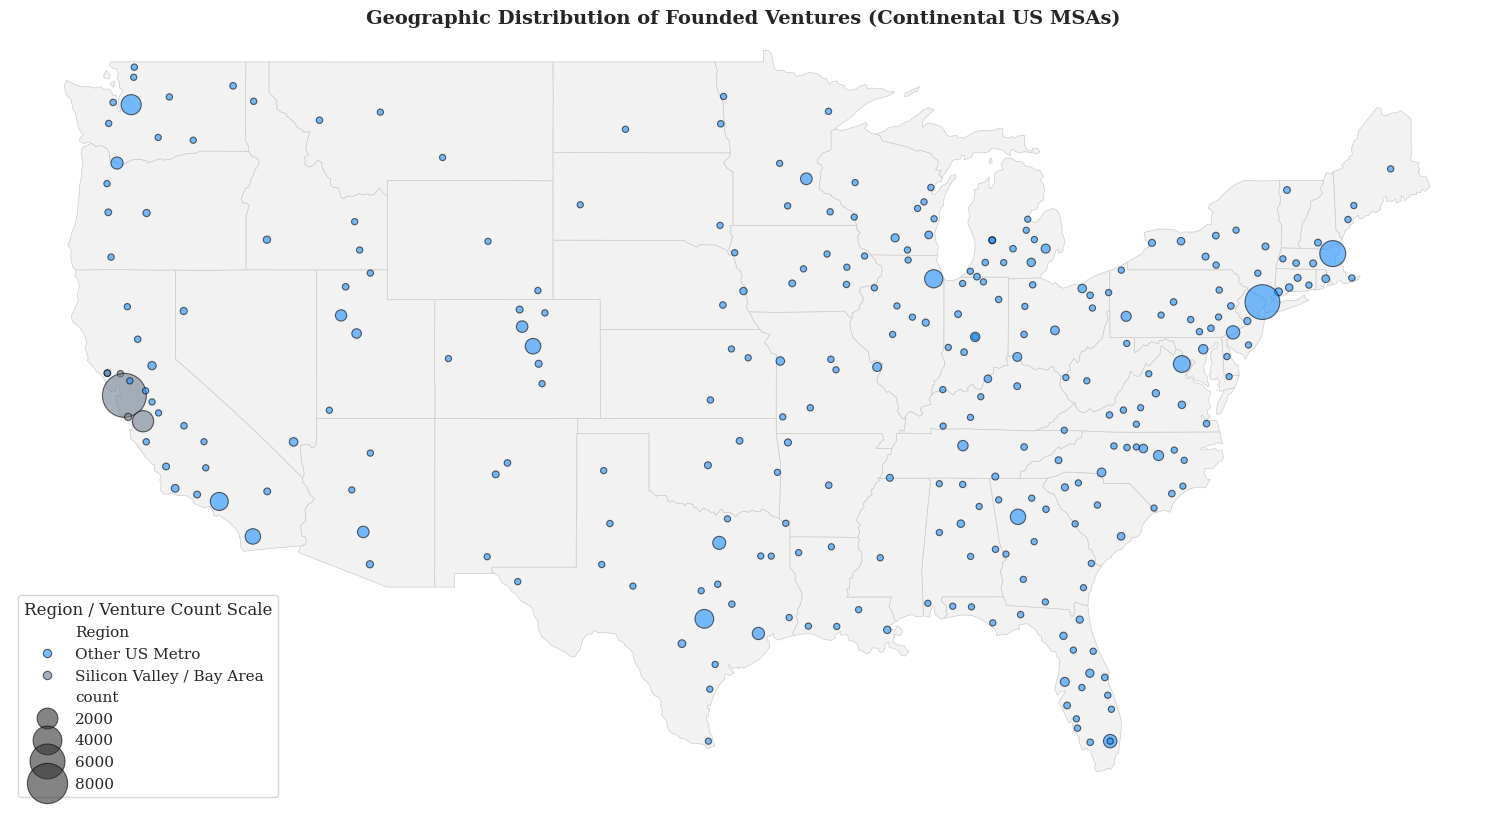

In [2]:
# Load Census CBSA shapefile and US State boundary outlines
print("Loading US State boundaries...")
us_states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
# Filter to continental US states
us_states = us_states[~us_states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico', 'Virgin Islands'])]

print("Loading official Census CBSA shapes...")
cbsa_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_cbsa_20m.zip"
cbsa_gdf = gpd.read_file(cbsa_url)

# Group dataset by venture_msa and is_sv to get counts
df_counts = df_filtered.groupby(['venture_msa', 'is_sv'])['user_id'].count().reset_index(name='count')

# Define name-matching logic
def clean_name(name):
    name = str(name).lower()
    name = name.replace(' msa', '')
    name = re.sub(r'[^\w\s]', ' ', name)
    return set(name.split())

print("Matching MSA names...")
mapping = {}
for v_msa in df_counts['venture_msa'].dropna().unique():
    v_words = clean_name(v_msa)
    best_match = None
    best_overlap = 0
    for s_name in cbsa_gdf['NAME'].dropna().unique():
        s_words = clean_name(s_name)
        overlap = len(v_words.intersection(s_words))
        if overlap > best_overlap:
            best_overlap = overlap
            best_match = s_name
    if best_overlap >= 2:
        mapping[v_msa] = best_match

df_counts['shape_name'] = df_counts['venture_msa'].map(mapping)

# Merge with centroids from shapefile
cbsa_gdf['lon'] = cbsa_gdf.geometry.centroid.x
cbsa_gdf['lat'] = cbsa_gdf.geometry.centroid.y

df_map = df_counts.merge(cbsa_gdf[['NAME', 'lon', 'lat']], left_on='shape_name', right_on='NAME', how='inner')
# Filter coordinates to continental US bounds
df_map = df_map[(df_map['lon'] > -130) & (df_map['lon'] < -65) & (df_map['lat'] > 20) & (df_map['lat'] < 50)]

# Plot Bubble Map overlaid on US outline with standard linear bubble size scaling
fig, ax = plt.subplots(figsize=(15, 10))
us_states.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.5)

# Color scheme
df_map['Region'] = df_map['is_sv'].map({True: 'Silicon Valley / Bay Area', False: 'Other US Metro'})

sns.scatterplot(
    data=df_map,
    x='lon',
    y='lat',
    size='count',
    sizes=(20, 1000),
    hue='Region',
    palette={'Silicon Valley / Bay Area': 'slategrey', 'Other US Metro': 'dodgerblue'},
    alpha=0.6,
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

plt.xlim(-127, -65)
plt.ylim(24, 50)
plt.title("Geographic Distribution of Founded Ventures (Continental US MSAs)", fontsize=14, fontweight='bold')
ax.axis('off')  # Remove axes border, ticks, grid, and labels
plt.legend(title="Region / Venture Count Scale", loc="lower left", frameon=True)
plt.tight_layout()

output_fig_dir = "/Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures"
os.makedirs(output_fig_dir, exist_ok=True)
fig_bubble_path = os.path.join(output_fig_dir, "venture_geographies_bubble_map.png")
plt.savefig(fig_bubble_path, dpi=300, bbox_inches='tight')
print(f"Saved bubble map to: {fig_bubble_path}")
plt.show()

/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_97830/1655001829.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cbsa_map_gdf = cbsa_map_gdf[cbsa_map_gdf.geometry.centroid.x.between(-130, -65) & cbsa_map_gdf.geometry.centroid.y.between(20, 50)]


Saved log-scale choropleth map to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/venture_geographies_choropleth_map.png


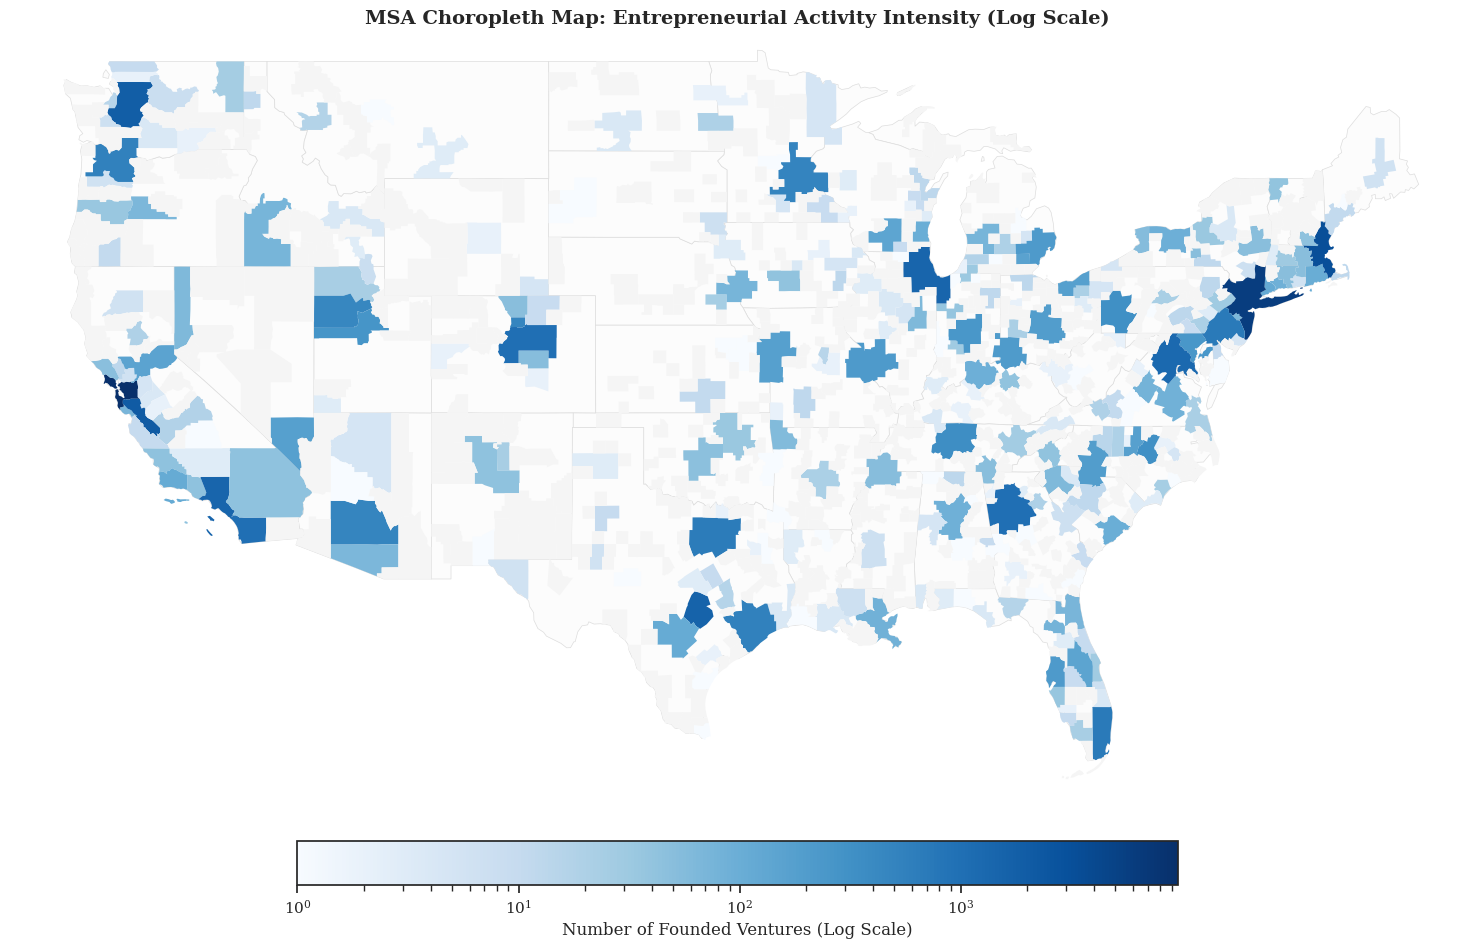

In [3]:
# Merge venture count onto the shapefile GDF
df_counts_agg = df_counts.groupby('shape_name')['count'].sum().reset_index()
cbsa_map_gdf = cbsa_gdf.merge(df_counts_agg, left_on='NAME', right_on='shape_name', how='left')
cbsa_map_gdf['count'] = cbsa_map_gdf['count'].fillna(0)

# Filter shapefile boundaries to continental US bounding box to keep output clean
cbsa_map_gdf = cbsa_map_gdf[cbsa_map_gdf.geometry.centroid.x.between(-130, -65) & cbsa_map_gdf.geometry.centroid.y.between(20, 50)]

# Plot Choropleth Map with LogNorm scale to make differences in entrepreneurial activity visible
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(15, 10))
# Draw background states boundaries in light grey
us_states.plot(ax=ax, color='#fcfcfc', edgecolor='#dddddd', linewidth=0.5)

# Set 0 values to NaN so they are colored as missing (light grey) rather than log(0) error
cbsa_map_gdf['count_clean'] = cbsa_map_gdf['count'].replace(0, np.nan)

# Draw MSA shapes color-coded by count on Log scale
cbsa_map_gdf.plot(
    ax=ax,
    column='count_clean',
    norm=colors.LogNorm(vmin=1, vmax=cbsa_map_gdf['count_clean'].max()),
    cmap='Blues',
    legend=True,
    legend_kwds={
        'label': 'Number of Founded Ventures (Log Scale)',
        'orientation': 'horizontal',
        'pad': 0.05,
        'shrink': 0.6
    },
    edgecolor='none',  # Keep it smooth by hiding boundary borders
    missing_kwds={'color': '#f5f5f5'}
)

plt.xlim(-127, -65)
plt.ylim(24, 50)
plt.title("MSA Choropleth Map: Entrepreneurial Activity Intensity (Log Scale)", fontsize=14, fontweight='bold')
ax.axis('off')  # Remove axes border, ticks, grid, and labels
plt.tight_layout()

fig_choropleth_path = os.path.join(output_fig_dir, "venture_geographies_choropleth_map.png")
plt.savefig(fig_choropleth_path, dpi=300, bbox_inches='tight')
print(f"Saved log-scale choropleth map to: {fig_choropleth_path}")
plt.show()

## 4. Reference to Main Classifications Document

The construction of geographic variables and their theoretical motivation is fully integrated with the role-level and industry-level classifications. For a comprehensive overview of variable coding schemas and LLM role mapping rules, refer to [C3.3 - Variable Construction and Classifications.ipynb](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20%5BPaper%202%5D/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.3%20-%20Variable%20Construction%20and%20Classifications.ipynb).